In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library.standard_gates import RYGate
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem, FasterAmplitudeEstimation
from itertools import product
from scipy.stats import norm, lognorm
from qiskit_aer import AerSimulator

# Standard pricing of a call option

The first part of this project consists in computing the price of a call option using the Black-Scholes closed formula, and then approximating it using a Monte Carlo method.

## Black-Scholes price of the call option

Definition of the function implementing the closed formula for the price of a call option

In [3]:
def black_scholes_call(S, K, T, r, sigma):
    """
    Calculate the Black-Scholes price for a European call option.
    
    :param S: Current stock price
    :param K: Strike price
    :param T: Maturity (in years)
    :param r: Risk-free interest rate (annual)
    :param sigma: Volatility of the stock (annual)
    :return: Call option price
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

### Characteristics to price the call option

In [4]:
# Financial characteristics that are also required to compute the probability distribution
sigma = 0.2 # volatility (annualized)
T = 1 # maturity (in years)
r = 0.05 # risk-free rate (annualized)
S0 = 2 # initial stock price
K = 2 # strike price

Evaluation of the price for the given set of parameters

In [5]:
call_price = black_scholes_call(S0, K, T, r, sigma)
print(f"Call option price: {call_price}")

Call option price: 0.20901167144371136


## Compounded Black-Scholes price of the call option

In this project, we are actually interested in the compounded value of the call price. Data is stored in dictionaries.

Dictionary for the pricing characteristics

In [6]:
price_dict = {'S0': S0, 'r': r, 'sigma': sigma, 'T': T}

In [7]:
def compound_black_scholes_call(price_dict, K):
    """
    Calculate the Black-Scholes price for a European call option.
    
    :param S: Current stock price
    :param K: Strike price
    :param T: Maturity (in years)
    :param r: Risk-free interest rate (annual)
    :param sigma: Volatility of the stock (annual)
    :return: Call option price
    """
    S0 = price_dict['S0']
    T = price_dict['T']
    r = price_dict['r']
    sigma = price_dict['sigma']
    call_price = black_scholes_call(S0, K, T, r, sigma)
    compound = np.exp(r * T)
    return compound * call_price

In [8]:
compound_call_price = compound_black_scholes_call(price_dict, K)
print(f"Compounded call option price: {compound_call_price}")

Compounded call option price: 0.21972792899401578


## Monte Carlo evaluation of the compounded price of the call option

Complete the code below to evaluate the compounded price of the call option. A sample of $\mathcal{N}(0,1)$ can be generated using the command `random.standard_normal` from **numpy**

In [9]:
def monte_carlo_black_scholes(price_dict, K, num_simulations):
    """
    Monte Carlo simulation for Black-Scholes option pricing.
    
    :param price_dict: Dictionary containing the pricing characteristics
    :param K: Strike price
    :param num_simulations: Number of Monte Carlo simulations
    :return: Option price
    """
    S = price_dict['S0']
    T = price_dict['T']
    r = price_dict['r']
    sigma = price_dict['sigma']
    # Generate random price paths and compute the corresponding payoffs

    payoff = 0
    for i in range(1, num_simulations+1):
        # Simulation of the the stock price at maturity
        G = np.random.normal(0, 1) # standard normal random variable
        ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * G) # stock price at maturity
        payoff += max(0, ST - K)
    
    # Discount the average payoff to present value
    compound_option_price = payoff / num_simulations
    
    return compound_option_price

In [10]:
monte_carlo_black_scholes(price_dict, K, 50000)

np.float64(0.22058163973989933)

<font color=green>The call price obtained with monte-carlo simulation is coherent with Black-scholes price.

The goal of the project is to implement a quantum algorithm that can be used to approximate the compounded price.

# Storing a linear function in a quantum state

## Presentation
The goal of this part is to construct a circuit that permits to encode an affine function $f: x\mapsto a + bx$ on $n$ qubits, under the constraint that $a$ and $b$ are such that $f(x) \in [0,1]$ for all $x\in \{0, \ldots, 2^n-1\}$.

The encoding is based on the approximation $\sin^2\left(y + \frac{\pi}{4}\right) = y + \frac{1}{2} + O\left(y^3\right)$, where $y$ is replaced by $d\cdot\left(f(x) + \frac{1}{2}\right)$.

## Encoding the affine function

Create a method `encode_affine_function`$(n,a,b)$ that encodes the function $f$ defined above using rotation gates. Recall that the circuit consists of $n+1$ qubits.

In [11]:
def encode_affine_function(n, a, b):
    circuit = QuantumCircuit(n+1)

    circuit.ry(a, 0) # Apply on the first qubit (payoff qubit)
    
    for i in range(n):
        b_i = b * (2**i)
        circuit.cry(b_i, i+1, 0) # Controlled rotation from qubit i+1 (because we have to leave the payoff qubit free) to the payoff qubit
    return circuit

## Testing the circuit

The goal of this part is to make sure that the designed circuit behaves as expected for all inputs.

### Helper functions for amplitude estimation on the constructed circuit

The functions below are provided so that they can be used to make sure the constructed circuit behaves as expected.

In [12]:
def to_bin(n, i):
    """
    Convert integer i to binary string of length n and append '1' to the end.
    """
    bini = format(i, f'0{n}b')
    res = bini + '1'
    return res
#to_bin(3, 2)

In [13]:
def get_state_probabilities(qc):
  """
  Retrieve the probabilities of each basis state from the statevector of the input quantum circuit.
  """
  n = qc.num_qubits
  statevector = Statevector(qc)
  probabilities = {}
  for i in range(2**n):
    # bin(i) converts i to binaray string, [2:] removes the '0b' prefix, and zfill(n) pads with zeros to ensure the string has length n
    state = bin(i)[2:].zfill(n)
    probabilities[state] = abs(statevector[i])**2  
  return probabilities



In [14]:
def get_output_prob(qc, i):
    '''For a circuit with n qubits, returns the probability of reading a '1' on qubit 0 when qubits 1 to n are in the state i'''
    n = qc.num_qubits - 1
    state_probs = get_state_probabilities(qc)
    output_prob = state_probs[to_bin(n,i)]
    return output_prob

Define a method `convert_affine`$(a,b,d)$ that outputs values `a_out` and `b_out` for the transformed affine function.

<font color=green>

The probability to measure $|1\rangle$ after 
$R_y(\theta)$ is $P(|1\rangle)=\sin^2(\frac{\theta}{2})$

And as $\sin^2\left(y + \frac{\pi}{4}\right) = y + \frac{1}{2}$, we can pose that $\frac{\theta}{2}=y+\frac{\pi}{4}$

We also have : $y=d\left(f(x)-\frac{1}{2}\right)$

Finally : 
\begin {align*}
    \theta &= 2d\left(f(x)-\frac{1}{2}\right)+\frac{\pi}{2} \\
    &= 2.d.b.x + 2d\left(a-\frac{1}{2}\right)+\frac{\pi}{2}
\end{align*}

$\theta_a = 2d\left(a-\frac{1}{2}\right)+\frac{\pi}{2}$

$\theta_b = 2.d.b.x$

In [15]:
def convert_affine(a, b, d):
    a_out = 2 * d * (a - 0.5) + np.pi/2
    b_out = 2 * d * b
    return a_out, b_out

Create an `initializer` function that takes as an input a quantum circuit consisting of $n$ qubits and an integer $0\leq i \leq 2^{n-1} -1$, and creates a new quantum circuit in which the initial state is $|i\rangle$ on the input qubits (and $|0\rangle$ on the output qubit).

In [16]:
def initializer(qc,n, i):

    binary_i = format(i, f'0{n}b')
    # Qiskit is little endian, so we need to reverse the binary string
    binary_i_rev = binary_i[::-1]

    # Apply X gates to qubits where the binary representation of i has a '1'
    for j in range(n):
        if binary_i_rev[j] == '1':
            qc.x(j+1) # Apply X gate to qubit j+1 (since qubit 0 is the payoff qubit)
    return qc
    

Create a method `compare_values`$(n,a,b,d,i)$ that compares the expected value 
$$d\cdot\left(f(i)-\frac{1}{2}\right) + \frac{1}{2} = d\cdot\left(a+i\cdot b - \frac{1}{2}\right) + \frac{1}{2}$$
with the probability of measuring value $1$ on qubit $0$ in the constructed circuit. The method should print the expected value, the probability of measuring the value $1$ and the relative error between both.

This method is in charge of:
- Invoking `convert_affine` to get the appropriate parameters for the encoded affine function
- Creating the initial circuit (`encode_affine_function`)
- Invoking the `initializer` to set the desired initial state
- Retrieving the probability of reading a $1$ on qubit $0$

In [17]:
def compare_values(n, a, b, d, i):
    # Convert the affine function parameters to the corresponding rotation angles
    a_out, b_out = convert_affine(a, b, d)

    # Create the quantum circuit and initialize the input state corresponding to i
    qc = QuantumCircuit(n+1)
    initializer(qc, n, i)

    # Apply the affine function encoding
    affine_circuit = encode_affine_function(n, a_out, b_out)
    qc.append(affine_circuit, range(n+1))
    
    # Get the probability of measuring '1' on the payoff qubit (qubit 0) for the input state i
    prob_1 = get_output_prob(qc, i)

    # Calculate the expected output of the affine function for input i
    expected_value = d * (a + b * i - 0.5) + 0.5

    # Calculate the relative error between the quantum output and the expected value
    rel_error = abs(prob_1 - expected_value) / expected_value

    # Print the results
    print(f"--- Compare Values i= {i}")
    print(f"Quantum Output: {prob_1:.6f}")
    print(f"Expected Value: {expected_value:.6f}")
    print(f"Relative Error: {rel_error:.2%}")
    print("-"*30)
    return rel_error

In [18]:
def compare_all_values(n, a, b, d):
    for i in range(2**n):
        compare_values(n, a, b, d, i)

### Definition of constants for testing purposes

In [19]:
# Number of qubits in the circuit
n_test = 3

# Arbitrary value for b
b_test = 1.0/(2**n_test)

# Arbitrary value for a, with the constraint that 0 <= f(x) <= 1 for all x
a_test = 1.0/(2**(n_test+1))

# Arbitrary value for d
d_test = 0.1

In [20]:
pure_affine = encode_affine_function(n_test, a_test, b_test)

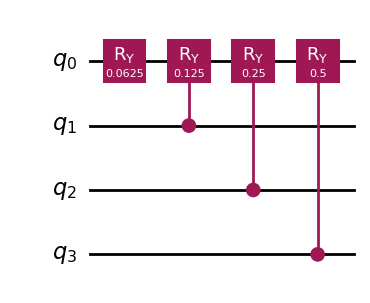

In [21]:
pure_affine.draw(output='mpl')

Invoking `compare_all_values` with the defined constants:

In [22]:
compare_all_values(n_test, a_test, b_test, d_test)

--- Compare Values i= 0
Quantum Output: 0.456306
Expected Value: 0.456250
Relative Error: 0.01%
------------------------------
--- Compare Values i= 1
Quantum Output: 0.468770
Expected Value: 0.468750
Relative Error: 0.00%
------------------------------
--- Compare Values i= 2
Quantum Output: 0.481254
Expected Value: 0.481250
Relative Error: 0.00%
------------------------------
--- Compare Values i= 3
Quantum Output: 0.493750
Expected Value: 0.493750
Relative Error: 0.00%
------------------------------
--- Compare Values i= 4
Quantum Output: 0.506250
Expected Value: 0.506250
Relative Error: 0.00%
------------------------------
--- Compare Values i= 5
Quantum Output: 0.518746
Expected Value: 0.518750
Relative Error: 0.00%
------------------------------
--- Compare Values i= 6
Quantum Output: 0.531230
Expected Value: 0.531250
Relative Error: 0.00%
------------------------------
--- Compare Values i= 7
Quantum Output: 0.543694
Expected Value: 0.543750
Relative Error: 0.01%
---------------

# Quantum circuit for integer comparison

The goal of this part is to construct a circuit of size $n$, parameterized by an integer $0\leq L \leq 2^n-1$, that permits to detect whether a given state $|i\rangle$ is such that $i < L$ or $i\geq L$.

## Creation of the 'or' gate

Define a method `or_gate`() that constructs a quantum circuit representing an *or* gate using the method described in the exercise sheet. Formally, the constructed gate $\mathrm{Or}$ should be such that
$$\mathrm{Or}\cdot|xyz\rangle = |xy\rangle \otimes |z\oplus (x \vee y)\rangle.$$

<font color=green>

$x \vee y = \neg (\neg x \land \neg y)$

We know that Toffoli gate (ccx) permits, with given qubits a, b, c to have at output a, b and $(c \oplus (a \land b))$.

So,

\begin{align*}
    \mathrm{Or}\cdot|xyz\rangle &= |xy\rangle \otimes |z\oplus (x \vee y)\rangle \\
    &= |xy\rangle \otimes |z\oplus \neg (\neg x \land \neg y)\rangle \\
    &= |xy\rangle \otimes |\neg z\oplus (\neg x \land \neg y)\rangle \\
\end{align*}

In [23]:
def or_gate():
    # Creation of a 3-qubit quantum circuit
    qc = QuantumCircuit(3, name='Or')

    # Invert the first two qubits
    qc.x(1) # x
    qc.x(2) # y

    # Invert the target qubit
    qc.x(0) # z
    # Apply a Toffoli gate with the first two qubits as controls and the target qubit as target
    qc.ccx(1, 2, 0)

    # Re-invert the first two qubits to restore their original state
    qc.x(1) # x
    qc.x(2) # y

    return qc

We can verify that the *or* gate has the appropriate behavior by computing the probabilities of measuring a $1$ on qubit $0$ for different initial states.


**Useful methods**: 
- The `initialize` and `get_output_prob` methods defined above.

In [24]:
def test_or_gate():
    print(f"{'Input (x,y)':<12} | {'Expected' : <10} | {'Quantum prob':<12}")
    print("-"*40)

    for i in range(4): # (00, 01, 10, 11)
        # Create a circuit of 3 qubits
        qc = QuantumCircuit(3)

        # Initialize qubits 1 and 2 to represent the input (x,y)
        initializer(qc, 2, i)

        # Apply the OR gate
        or_circuit = or_gate()
        qc.append(or_circuit, range(3))

        # Get the probability of measuring '1' on the target qubit (qubit 0)
        prob_1 = get_output_prob(qc, i)

        # Calculate the expected output of the OR function for input (x,y)
        x = (i >> 1) # Get the value of the first bit (x)
        y = (i & 1)
        expected_output = x | y

        print(f"{bin(i)[2:].zfill(2):<12} | {expected_output:<10} | {prob_1:.2f}")

In [25]:
test_or_gate()

Input (x,y)  | Expected   | Quantum prob
----------------------------------------
00           | 0          | 0.00
01           | 1          | 1.00
10           | 1          | 1.00
11           | 1          | 1.00


## Construction of the comparator circuit

Define a `make_comparator`$(n,L)$ function that creates a circuit of size $2n$ such that, when state $|i\rangle \otimes |0^n\rangle$ is fed as an input, we have $|q_0\rangle = |0\rangle$ exactly when $i < L$. 

<font color=green>

To compare an $n-bit$ quantum integer i with a constant threshold L, we distribute our 2n qubits as follows:

- Result Qubit ($q_0$​): Stores the final comparison result.
- Input Qubits ($q_1$​ to $q_n$​): Store the binary representation of $i$.
- Ancilla Qubits ($q_{n+1​}$ to $q_{2n−1}$​): Serve as a temporary workspace. They act as a memory chain to track if the numbers are still equal as we scan the bits.

IMPLEMENTATION

The circuit must mark the state of the first qubit ($q_0$) as follows:

- if $i \lt L : |q_0 \rangle = |0\rangle$ (True)
- if $i\ge L : |q_0 \rangle = |0\rangle$ (False)

1- Bitwise Propagation (MSB to LSB)
We compare the numbers bit by bit, starting from the Most Significant Bit (MSB) down to the Least Significant Bit (LSB). This is crucial: if a difference is found on a high-value bit (e.g., 2^3), the lower bits (e.g., 2^0) should no longer be able to change the result.

2- The Zero Detector (X Gates)
Zero Detector (X gates): The Toffoli gate (ccx) is only activated if it receives $|1\rangle$. To test if a bit of i is $|0\rangle$ (which is necessary if the corresponding bit of L is 0), we apply an x gate before the comparison to disguise the $|0\rangle$ as $|1\rangle$, then we apply it again afterward to restore the initial state (uncomputation).

3- The Equality Chain (CCX Gates)
The ancillas are used to create a persistent equality state.

- An ancilla at level j will only be activated if the previous ancilla was active AND the current bits are equal.
- Once this chain is broken (the bits differ), all subsequent ancillas remain at $|0\rangle$. This locks the circuit and prevents lower-weight bits from interfering with a result already determined by higher-weight bits.

4- Final inversion
By default, quantum logic produces a $|1\rangle$ for success. According to the statement, we apply a final inversion to ensure that the success is represented by $|q_0\rangle$=$|0\rangle$

Note on the first bit : Since the first bit (MSB) has no previous comparison to rely on, we use a CX gate instead of a CCX to initialize the equality chain and the result bit.



In [26]:
def make_comparator(n, L):
    # i: qubits 1 to n | result: q0 | Ancillas: n+1 to 2n-1
    qc = QuantumCircuit(2 * n, name='Comparator')
    L_bin = format(L, f'0{n}b')[::-1] # L in binary (L0 at index 0)
    
    # We use q0 as the direct accumulator for the result i < L
    # (Initially q0 is assumed to be 0)
    
    # We iterate over the bits of L from the most significant bit to the least significant bit
    for j in range(n - 1, -1, -1):
        bit_L = int(L_bin[j])
        idx_i = j + 1
        
        # For the most significant bit, we can directly determine if i < L based on the value of i_j and bit_L
        if j == n - 1: 
            if bit_L == 1:
                # i < L if i_j = 0
                qc.x(idx_i)
                qc.cx(idx_i, 0)
                qc.x(idx_i)
                # Equality : we store in the ancilla n + j if i_j = 1 (i.e. if we are still equal at this bit)
                qc.cx(idx_i, n + j)
            else:
                # Equality : we store in the ancilla n + j if i_j = 0
                qc.x(idx_i)
                qc.cx(idx_i, n + j)
                qc.x(idx_i)
        else:
            # For the following bits, we depend on the ancilla of the above bit to know if we are still in the equality case (i.e. all the above bits were equal).
            eq_prev = n + j + 1
            if bit_L == 1:
                # i < L if (Equality so far) AND (i_j = 0)
                qc.x(idx_i)
                qc.ccx(idx_i, eq_prev, 0)
                qc.x(idx_i)
                # Equality maintained if (Equality so far) AND (i_j = 1)
                if j > 0: # No need for ancilla after the last bit
                    qc.ccx(idx_i, eq_prev, n + j)
            else:
                # No i < L possible here because L=0.
                # Equality maintained if (Equality so far) AND (i_j = 0)
                if j > 0:
                    qc.x(idx_i)
                    qc.ccx(idx_i, eq_prev, n + j)
                    qc.x(idx_i)

    # Invert the result because we want to have q0 = 0 if i < L
    qc.x(0)
    return qc

Define a `check_comparison`$(n,L)$ method that invokes the `make_comparator` method, iterates over $0\leq i\leq 2^n-1$ to initialize the circuit with state $|i\rangle \otimes |0^n\rangle$ and verifies that the measurement of qubit $0$ returns the appropriate value for each value of $i$.

You can use the `get_one_prob` method below, which permits to compute the probability of reading value '1' on qubit $0$ upon a measurement. 

In [27]:
def get_one_prob(qc):
    """
    For a circuit with n qubits, returns the probability of reading a '1' on qubit 0
    """
    state_probs = get_state_probabilities(qc)
    n = qc.num_qubits - 1
    result = 0
    for i in range(2**n):
        bin_i = to_bin(n, i)
        result += state_probs[bin_i]
    return result

In [28]:
def check_comparison(n, L):
    # Create the comparator circuit for the given threshold L
    comparator_circuit = make_comparator(n, L)

    print(f"Comparator test (Threshold L={L})")
    print(f"{'Input i':<10} | {'Condition i < L':<15} | {'Prob(q0=1)':<12} | {'Result'}")
    print("-" * 60)

    for i in range(2**n):
        # Create a circuit of 2n qubits
        qc = QuantumCircuit(2*n)

        # Initialize the first n qubits to represent the input
        initializer(qc, n, i)

        # Apply the comparator circuit
        qc.append(comparator_circuit, range(2*n))

        # Get the probability of measuring '1' on the target qubit (qubit 0)
        prob_1 = get_one_prob(qc)

        # Calculate the expected output of the comparator for input i
        is_less = (i < L)
        expected_prob = 0.0 if is_less else 1.0

        # Determine if the test passed or failed based on the expected probability
        status = "OK" if abs(prob_1 - expected_prob) < 0.1 else "ERROR"

        print(f"{bin(i)[2:].zfill(n):<10} | {str(is_less):<15} | {prob_1:<12.2f} | {status}")

Comparator test (Threshold L=8)
Input i    | Condition i < L | Prob(q0=1)   | Result
------------------------------------------------------------
0000       | True            | 0.00         | OK
0001       | True            | 0.00         | OK
0010       | True            | 0.00         | OK
0011       | True            | 0.00         | OK
0100       | True            | 0.00         | OK
0101       | True            | 0.00         | OK
0110       | True            | 0.00         | OK
0111       | True            | 0.00         | OK
1000       | False           | 1.00         | OK
1001       | False           | 1.00         | OK
1010       | False           | 1.00         | OK
1011       | False           | 1.00         | OK
1100       | False           | 1.00         | OK
1101       | False           | 1.00         | OK
1110       | False           | 1.00         | OK
1111       | False           | 1.00         | OK


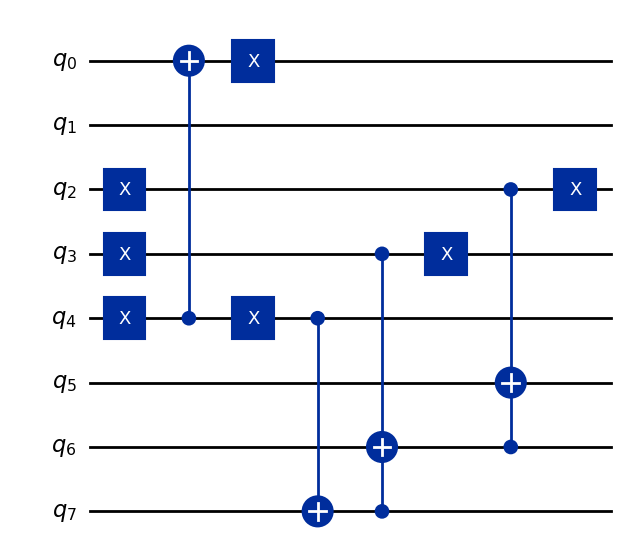

In [29]:
check_comparison(4, 8)
circuit = make_comparator(4, 8)
circuit.draw(output='mpl')

# Storing a probability distribution in a quantum state

The goal of this part is to design a circuit that permits to store a probability distribution in a quantum state.

## Case where $n=2$

We begin with the simple case where $n=2$. Complete the cell below to construct the circuit permitting to store the probability distribution in a quantum state (with a single qubit). 

<font color=green>

We have : 
$$|\psi\rangle = \sqrt{p_0}|0\rangle + \sqrt{p_1}|1\rangle$$
with $p_0$ the probability to measure $|0 \rangle$ and $p_1$ for $|1 \rangle$

$$R_y(\theta) = \begin{pmatrix} 
    \cos(\frac{\theta}{2}) & -\sin(\frac{\theta}{2}) \\ 
    \sin(\frac{\theta}{2}) & \cos(\frac{\theta}{2}) 
\end{pmatrix}$$

$$cos\left(\frac{\theta}{2}\right) = \sqrt{p_0} \Rightarrow \theta = 2.arccos(\sqrt{p_0})$$
$$sin\left(\frac{\theta}{2}\right) = \sqrt{p_1} \Rightarrow \theta = 2.arcsin(\sqrt{p_1})$$

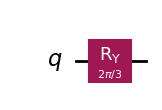

In [30]:
def store_probability_2(p0, p1) :
    # Check that p0 + p1 = 1
    assert np.isclose(p0 + p1, 1.0), "Probabilities must sum to 1"

    # INitialisation of the circuit
    qc = QuantumCircuit(1)

    # Calculation of the angle for the Ry rotation to encode the probabilities
    theta = 2 * np.arcsin(np.sqrt(p1))
    # Apply the Ry rotation to the qubit
    qc.ry(theta, 0)
    return qc
circuit_p = store_probability_2(0.25, 0.75)
circuit_p.draw('mpl')

With a correctly implemented circuit, the probability of getting the outcome $0$ is close to $p$, likewise for $1$ and $1-p$.

## Circuit for an arbitrary value of $n$.

### Generation of the final prices grid

Use the `linspace` method from **numpy** to define a method `make_final_price_grid`$(n, \mathrm{price\_dict}, m)$ that generates a regular grid with size $2^n$ of final prices ranging between $\max\left(0, \overline{S} - m\cdot \sigma\right)$ and $\overline{S} + m\cdot \sigma$.

<font color=green>

Knowing $S_0$, $r$ and $T$, we can calculate $\bar{S}$ under the risk-neutral measure by : 

$$\bar{S} = S_0 e^{rT}$$

And standard deviation converted to currency will be :

$$\sigma_T = S_0.\sigma.\sqrt{T}$$

In [31]:
def get_boundary(n, price_dict, m):

    # Extraction of parameters from the price_dict
    S_bar = price_dict['S0'] * np.exp(price_dict['r'] * price_dict['T'])
    std_t = price_dict['S0'] * price_dict['sigma'] * np.sqrt(price_dict['T'])
    
    # Definition of boundaries for the grid
    S_min = max(0, S_bar - m * std_t)
    S_max = S_bar + m * std_t

    return S_min, S_max

In [32]:
def make_final_price_grid(n, price_dict, m):

    # Calculate the number of points in the grid
    grid_size = 2**n

    # get the boundaries for the grid
    S_min, S_max = get_boundary(n, price_dict, m)

    # Generation of the grid
    prices_grid = np.linspace(S_min, S_max, grid_size)
    return prices_grid

Define a method `align`$(n, K, \mathrm{price\_dict}, m)$ that returns the value $L$ such that $s_L$ is the projection of $K$ on the final price grid.

<font color=green>
Let's imagine the grid as a graduated ruler :

- The distance between the minimum price ($S_{min}$) and the maximum one ($S_{max}$) is divided into $N-1$ segments, where $N=2^n$.

- We look at where K is located relative to the beginning of the ruler ($S_{min}$). So $K-S_{min}$

- By dividing this distance by the size of a segment (the step size), we obtain a real number. We use round() to find the index of the nearest quantum state. 

NB: We must check if $K$ is between the boundaries of our price grid

In [33]:
def align(n, K, price_dict, m):
    S_min, S_max = get_boundary(n, price_dict, m)

    # Check that K is within the boundaries
    if K <= S_min :
        return 0, S_min
    if K >= S_max :
        return 2**n - 1, S_max

    # Calculate the position of K in the grid
    grid_interval = (S_max - S_min) / (2**n - 1)

    L = int(round((K - S_min) / grid_interval))

    # Calculate the corresponding price in the grid for verification
    s_L = S_min + L * grid_interval
    return (L, s_L)

Test the discretization error by comparing the outputs of `compound_black_scholes_call` on an arbitrary strike and on its projection on the final price grid.

In [34]:
init_cpb = compound_black_scholes_call(price_dict, price_dict['S0'])
disc_cpb_5 = compound_black_scholes_call(price_dict, align(5,price_dict['S0'], price_dict, 3)[1])
# with n=8
disc_cpb_8 = compound_black_scholes_call(price_dict, align(8,price_dict['S0'], price_dict, 3)[1])

In [35]:
print(f'init: {init_cpb}, disc: {disc_cpb_5}, error: {(init_cpb-disc_cpb_5)/init_cpb:.2%}')
print(f'init: {init_cpb}, disc: {disc_cpb_8}, error: {(init_cpb-disc_cpb_8)/init_cpb:.2%}')

init: 0.21972792899401578, disc: 0.2274224348053514, error: -3.50%
init: 0.21972792899401578, disc: 0.21765371689246135, error: 0.94%


<font color=green>

- Convergence of Accuracy: The error drops significantly as the number of qubits increases, from -3.5% to less than 1%. This validates the robustness of our align function.

- Error Oscillation: The change in the error sign (-3.50% to +0.94%) perfectly illustrates the nature of the discretization. Depending on whether the nearest grid point ($s_L$) is located just above or just below the continuous value $S_0$, the option price oscillates around its theoretical value.

- Benchmark Validation: The accuracy obtained with 8 qubits (error $\lt$ 1%) is excellent for use as a benchmark in future Quantum Amplitude Estimation (QAE) steps.

### Generation of the probability values

Define a method `make_probability_distribution` that returns a tuple with the last prices grid and the corresponding value of each $p_i$ for $0 \leq i < 2^n$. The arguments of this method are:
- $n$: the number of qubits under consideration
- $\mathrm{price\_dict}$: the dictionary with the mathematical characteristics of the underlying
- $m$: the number of standard deviations to consider for the minimum and maximum bounds of the grid

***Useful methods:*** 
$S_T$ is of the form $S_0e^{(r-\tfrac{\sigma^2}{2})T}\cdot Z$, where $Z \sim \mathrm{lognorm}(\sigma\sqrt{T})$. The lognormal distribution is available thanks to the `lognorm` method from `scipy.stats`. The `scale` parameter is to be set to $1$.

The probability values can be computed using the `cdf` method available on the lognormal distribution.

<font color=green>

Before coding the probability distribution, it is essential to understand how we model the price of the financial asset and how we adapt this continuous model to a discrete quantum computer.

$\textbf{1. The Black-Scholes Model and the Log-Normal Distribution}$

In finance, the price of an asset $S_T$ at time $T$ is assumed to follow a geometric Brownian motion. Unlike a normal distribution, which can be negative, the price of a stock follows a log-normal distribution.

The formula for the price at time T is given by:
$$ S_T = S_0 exp\left(\left(r-\frac{\sigma^2}{2} \right)T + \sigma \sqrt{T}\cdot \epsilon \right) $$
where $\epsilon \sim \mathrm{N}(0, 1)$ is a standard normal variable. To use `scipy's` `lognorm` function, we rewrite this expression as:
$$ S_T = scale \cdot Z$$
with :

- $z$ A standardized log-normal distribution with parameter $s = \sigma T$ and $scale=1$ 
- $scale$: The scale factor (median of the distribution) defined by $S_0e^{(r-\tfrac{\sigma^2}{2})T}$

$\textbf{2. Discretization on the Grid}$

A quantum computer with $n$ qubits can represent exactly $N=2^n$ distinct values. Therefore, we must divide our continuous price space into $N$ intervals (or bins).

Each point $s_i$ on our grid actually represents a small interval $[a_i, b_i]$ centered around that price. The probability $p_i$ associated with the quantum state $|i \rangle$ is the probability that the final price $S_T$ falls within this interval:
$$ p_i = P(a_i \le S_T \le b_i)$$

$\textbf{3. Calculation using the Distribution Function (CDF)}$

To calculate this probability precisely, we use the CDF (Cumulative Distribution Function), denoted $F(x)$, which gives $P(S_T \le x)$. The probability for each point $i$ on the grid is:
$$p_i = F(b_i) - F(a_i)$$
Since we set $scale=1$ in the `lognorm` function, we must normalize our grid bounds by the financial scale factor:
$$ p_i = CDF_{lognormal}\left(\frac{b_i}{scale}, s \right) - CDF_{lognormal}\left(\frac{a_i}{scale}, s \right) $$

$\textbf{4. Quantum normalisation}$

Finally, since our grid is limited to a finite interval (defined by $m$ standard deviations), the sum of the calculated probabilities can be slightly less than 1. For the resulting quantum state to be:
$$ |\psi \rangle = \sum_{i=0}^{2^n-1} \sqrt{p_i} |i \rangle $$
to be valid, we perform a final normalization so that $\sum p_i​=1$. This guarantees that the measurement of the quantum circuit will always give a result among the states of our grid.




In [36]:
def make_probability_distribution(n, price_dict, m):
    # Retrieval of the grid of possible final prices
    grid = make_final_price_grid(n, price_dict, m)
    
    # Stastical parameters of the log-normal distribution of the final price
    sigma_t = price_dict['sigma'] * np.sqrt(price_dict['T'])

    # Scale factor
    mu = (price_dict['r'] - 0.5 * price_dict['sigma']**2) * price_dict['T']
    S_scale = price_dict['S0'] * np.exp(mu)
    
    # Creation of the log-normal distribution with scale=1 (we will adjust the grid accordingly)
    dist = lognorm(s=sigma_t, scale=1)
    
    # Calculation of probabilities for each point in the grid by integrating the log-normal distribution over the corresponding interval
    p_values = []
    num_points = 2**n
    step = (grid[-1] - grid[0]) / (num_points - 1)
    
    for i in range(num_points):
        # Adjust the grid points to "enter" the distribution where scale=1
        a_i_scaled = (grid[i] - step / 2) / S_scale
        b_i_scaled = (grid[i] + step / 2) / S_scale
        
        # Probability on the standardized variable 
        p_i = dist.cdf(b_i_scaled) - dist.cdf(a_i_scaled)
        p_values.append(p_i)
    
    p_values = np.array(p_values)
    # Normalization of the probabilities to ensure they sum to 1
    p_values /= np.sum(p_values) 
    
    return grid, p_values

## Validation of the probability distribution, comparison of the Black-Scholes approximation

In [37]:
# Arbitrary value for n, will afterward be the size of the quantum circuit
n_prob = 10
n_stddev_prob = 4

Verify that the generated distribution sums to $1$.

In [38]:
final_prices, prob_distribs = make_probability_distribution(n_prob, price_dict, n_stddev_prob)
np.sum(prob_distribs)

np.float64(1.0)

Plot the generated distribution against the final price grid.

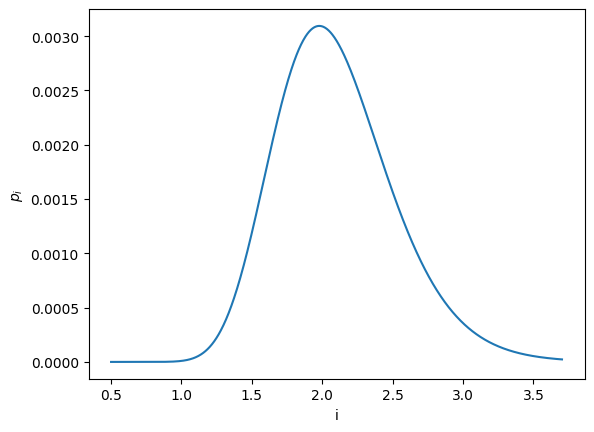

In [39]:
plt.plot(final_prices, prob_distribs)
plt.xlabel('i')
plt.ylabel('$p_i$')
plt.show()

Compare the compounded Black-Scholes price of an option with the approximation of the expectation 
$$\mathbb{E}\left[(S_T - s_L)_+\right] \approx \sum_{i=0}^{2^n-1}p_i\cdot(s_i - s_L)_+.$$

In [40]:
def expectation_cmp(n, L, price_dict, n_stddev):
    last_prices, prob_distribs = make_probability_distribution(n, price_dict, n_stddev)
    
    # Retrieval of the price corresponding to the index L in the grid (Strike aligned with the grid)
    sL = last_prices[L]
    
    # Calculation of the option price using the Black-Scholes formula with the aligned strike sL
    compound_bs = compound_black_scholes_call(price_dict, sL)
    
    # Calculation of discretized expectation of the payoff (S_T - sL)+ using the probability distribution obtained previously
    sum = 0
    for i in range(len(last_prices)):
        payoff = max(0, last_prices[i] - sL)
        sum += prob_distribs[i] * payoff
    return {'bs': compound_bs, 'sum': sum, 'strike': sL}

In [41]:
def get_all_expect_comp(n, price_dict, num_stddev, num_points):
    res = []
    for L in range(0, 2**n,int(2**n/num_points)):
        ex_cmp = expectation_cmp(n, L, price_dict, num_stddev)
        print(f'L: {L} (strike {ex_cmp["strike"]})')
        res.append(ex_cmp)
    return res

In [42]:
res = get_all_expect_comp(n_prob, price_dict,n_stddev_prob, 20)

L: 0 (strike 0.5025421927520481)
L: 51 (strike 0.6620729845409045)
L: 102 (strike 0.8216037763297608)
L: 153 (strike 0.981134568118617)
L: 204 (strike 1.1406653599074734)
L: 255 (strike 1.3001961516963296)
L: 306 (strike 1.4597269434851858)
L: 357 (strike 1.6192577352740423)
L: 408 (strike 1.7787885270628987)
L: 459 (strike 1.938319318851755)
L: 510 (strike 2.097850110640611)
L: 561 (strike 2.2573809024294675)
L: 612 (strike 2.4169116942183235)
L: 663 (strike 2.57644248600718)
L: 714 (strike 2.7359732777960364)
L: 765 (strike 2.895504069584893)
L: 816 (strike 3.0550348613737492)
L: 867 (strike 3.2145656531626052)
L: 918 (strike 3.3740964449514617)
L: 969 (strike 3.533627236740318)
L: 1020 (strike 3.693158028529174)


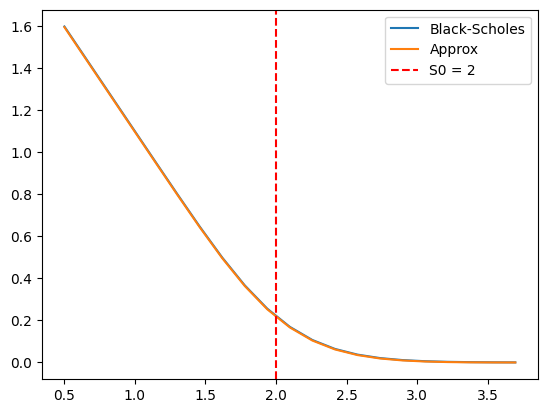

In [43]:
resbs = [x['bs'] for x in res]
ressum = [x['sum'] for x in res]
strikes = [x['strike'] for x in res]
xcoord = price_dict['S0']
plt.plot(strikes, resbs, label='Black-Scholes')
plt.plot(strikes, ressum, label='Approx')
plt.axvline(x=xcoord, color='r', linestyle='--', label=f'S0 = {xcoord}')
plt.legend()
plt.show()

<font color=green>

This graph shows the option price (Call) as a function of the strike price.

- Near-perfect overlap : The blue curve (theoretical) and the orange curve (our discrete approximation) are almost identical. This proves that our calculation method using the weighted sum $\sum p_i(s_i-K)_+$ is an excellent approximation of the continuous model.

- The Call form : The decreasing price of the Call option is clearly visible. The higher the strike price, the lower the option's value.

- The $S_0=2$ zone : To the left of the red line ($K \lt S_0$), the option is in-the-money (expensive). To the right ($K \gt S_0$), it is out-of-the-money (inexpensive). Our grid perfectly covers these two regimes.

In [44]:
abs_errors = [(x['sum'] - x['bs']) for x in res]

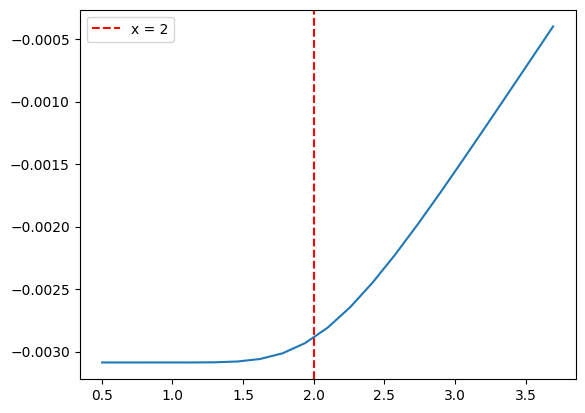

In [45]:
plt.plot(strikes, abs_errors)
xcoord = price_dict['S0']
plt.axvline(x=xcoord, color='r', linestyle='--', label=f'x = {xcoord}')
plt.legend()
plt.show()

<font color=green>

The graph shows the plot of `abs_errors = Approx - Black-Scholes`.

Order of magnitude : At the Y-axis the error is on the order of $-0.0030$ to $-0.0005$. This is a very small error (less than 0.3% compared to the option prices, which go up to 1.6). Our approximation is therefore very good.

The error profile :

- For small strikes (on the left), the error is constant and negative. This often comes from the truncation of the grid (the well-known standard deviations).

- The dip at $S_0$: We notice that the error changes behavior around the red line ($x=2$). This is normal: it's the area where the probability is highest and where the curvature of the payoff function is most pronounced. This is where the discretization is most sensitive.

Negative sign : The fact that the error is mostly negative means that our discrete approximation (`sum`) very slightly underestimates the theoretical price (`bs`). This is typical behavior when using a finite grid that cuts off the tails of the log-normal distribution.


<font color=green>

$\textbf{CONCLUSION ABOUT COMPARISON}$

Graphical analysis confirms the validity of our discretization. Comparison between the theoretical Black-Scholes price and the expected value calculated on the grid shows an extremely low maximum absolute error (less than 0.003 monetary units). The evolution of the error with respect to the strike price highlights the model's accuracy at the point $S_0=2$, thus validating the use of this price grid and probability distribution for implementation on a quantum circuit.

## Recursive distribution computations

We compute  the values $q_w$ and $\theta_w$. The values of $q_w$ (resp. $\theta_w$) where $w$ is of length $m$ are stored in a dictionnary where each key is a string of length $m$. The dictionnaries with the values of $q$ (resp. $\theta$) for $1 \leq m \leq n$ are stored in a dictionnary `DictQ` (resp. `DictTheta`).

Define a function `generate_binary_strings` that takes a parameter $n$ and outputs a list of all binary strings of length $n$.

Useful method: `product` from the `itertools` package

In [46]:
def generate_binary_strings(n):
    """ 
    Generate all binary strings of length n.
    For example, for n=2, the output will be ['00', '01', '10', '11'].
    """
    # product(range(2), repeat=n) generate tuples like (0,0), (0,1), (1,0), (1,1) for n=2
    # We then join the tuples to form binary strings
    return [''.join(map(str, bits)) for bits in product(range(2), repeat=n)]

Define a method `make_dict_at_n` that creates the dictionary containing the values $q_w$ where $w$ is of length $n$. This method has two parameters:
- the value of $n$
- the initial probability distribution

In [47]:
def make_dict_at_n(n, prob_distribution):
    # Generate all binary strings of length n
    binary_strings = generate_binary_strings(n)

    # Create a dictionary mapping each binary string to its corresponding probability
    dict_q_n = {binary_strings[i]: prob_distribution[i] for i in range(len(binary_strings))}

    return dict_q_n

Define a method `make_all_dictQ` that iterates from $n-1$ to $1$ to generate all the required probability distributions. Note that the set of keys in the generated dictionary is $\{1, \ldots, n\}$. This method has two parameters:
- the value of $n$
- the dictionary containing the probability distribution at level $n$ (generated by `make_dict_at_n`)

<font color=green>

To construct `make_all_dictQ`, we will adopt a bottom-up approach. The idea is simple : the probability of a parent node (a chain of length m) is the sum of the probabilities of its two children (chains of length m+1).

$\textbf{Construction Logic}$

If we know all the values ​$q_w$ of length $n$, we can find those of length $n−1$ by grouping the pairs:

$$ q_0 = q_{00} + q_{01} \\ q_1 = q_{10} + q_{11}$$

And so on up to the root of the tree.

In [48]:
def make_all_dictQ(n, dict_q_n):
    # Initalization of the list of dictionaries with the first one being the one at n
    DictQ = {n: dict_q_n}

    # We iterate from n-1 to 1 (going down in the precision, but going up in the tree)
    for i in range(n-1, 0, -1):
        current_level_dict = {}

        # generate all binary strings of length i
        binary_strings_i = generate_binary_strings(i)

        # for each channel w of length i, we calculate the corresponding probability distribution by summing the probabilities of the channels of length i+1 that are in the subtree of w
        for w in binary_strings_i:
            q_w0 = DictQ[i + 1][w + '0']
            q_w1 = DictQ[i + 1][w + '1']
            current_level_dict[w] = q_w0 + q_w1
    
        # We add the dictionary of the current level to the list of dictionaries
        DictQ[i] = current_level_dict
        
    return DictQ

Define a method `make_all_dictTheta` that iterates from $0$ to $n-1$ to generate all the required angles. Note that the set of keys in the generated dictionary is $\{0, \ldots, n-1\}$. This method has a single parameter: the dictionary generated by `make_all_dictQ`.

For the sake of convenience, the element at key $0$ in the generated dictionary will be the angle $\theta^{[0]}_\varepsilon$ instead of a dictionary containing this angle (with the empty string as a key).

<font color=green>

Let's imagine a node $w$ of our tree. We already have a total probability $q_w$. We want that the next qubit divide that probability in two branches : $q_{w0}$ and $q_{w1}$.

So we're looking for the angle $\theta_w$ such that the proportion of probability going towards $|1\rangle$ is exactly $\frac{q_{w1}}{q_w}$

$$ sin^2\left(\frac{\theta_w}{2}\right) = \frac{q_{w1}}{q_w} \Rightarrow \theta_w = 2arcsin \left(\sqrt{\frac{q_{w1}}{q_w}}\right) $$

In [49]:
def make_all_dictTheta(DictQ):
    """
    Generate the list of dictionaries containing the angles theta for each channel at 
    each level of the tree, based on the list of dictionaries containing the probabilities q 
    for each channel at each level of the tree.
    """
    # Extract the maximum level n from the keys of DictQ
    n = max(DictQ.keys())
    
    DictTheta = {}
    
    # Level 0 (root of the tree)
    # The total probability q_empty is always 1.
    # We look at the distribution between the left half (q_0) and the right half (q_1)
    q0 = DictQ[1]['0']
    q1 = DictQ[1]['1']

    # theta = 2 * arcsin(sqrt(q1 / (q0 + q1)))
    DictTheta[0] = 2 * np.arcsin(np.sqrt(q1 / (q0 + q1)))
    
    # Levels 1 to n-1
    for m in range(1, n):
        level_theta = {}
        # Retrieve all the channels at level m (binary strings of length m)
        binary_strings_m = generate_binary_strings(m)
        
        for w in binary_strings_m:
            qw = DictQ[m][w]
            
            if qw > 0:
                # Retrieve the probabilities of the right child (w1) of the channel w
                qw1 = DictQ[m + 1][w + '1']
                # Compute the angle theta
                level_theta[w] = 2 * np.arcsin(np.sqrt(qw1 / qw))
            else:
                level_theta[w] = 0.0
                
        DictTheta[m] = level_theta
        
    return DictTheta


Define a method `make_qc_for_dict` that creates the general quantum circuit for the storage of a quantum distribution. This method has a unique parameter: the dictionary of rotation angles (generated by `make_all_dictTheta`).

Some useful concepts and methods from Qiskit:
- `RYGate` for $y$-rotation gates that are potentially controlled
- `control`: the method to create the controlled version of a quantum gate. This method takes as parameters the number of control qubits, and possibly the state of the control qubits that will trigger the gate (`ctrl_state`).

In [50]:
def make_qc_for_dict(DictTheta):
    # Extract the maximum level n from the keys of DictTheta
    # Since DictTheta contains keys from 0 to n-1, n = max_key + 1
    n = max(DictTheta.keys()) + 1
    
    # Circuit initialization
    qc = QuantumCircuit(n)
    
    # Rotation on the first qubit (the root of the tree)
    # No control here since it's the first rotation
    theta_0 = DictTheta[0]
    qc.ry(theta_0, n-1) # Qiskit is little endian
    
    # Controlled rotations for levels 1 to n-1
    for m in range(1, n):
        # Retrieve the angles for the current level m
        level_angles = DictTheta[m]
        
        for w, theta in level_angles.items():
            if abs(theta) < 1e-10:
                # There's no need to add a door for a zero angle
                continue
                
            # Create the RY gate for the current angle
            ry_gate = RYGate(theta)
            
            # Controls and target for the controlled RY gate:
            # num_ctrl_qubits = len(w) = m
            # ctrl_state = w (Qiskit contains string binary control states, so we can directly use w as the ctrl_state)
            controlled_ry = ry_gate.control(num_ctrl_qubits=len(w), ctrl_state=w[::-1])
            
            # Gate application:
            # The controls are the qubits from 0 to m-1
            # The target is the qubit m
            target_qubit = n-1 - m
            control_qubits = [n-1 - j for j in range(m)] # We reverse the order of the control qubits because of the little endian convention
            qc.append(controlled_ry, control_qubits + [target_qubit])

    return qc
    

## Example

In [51]:
n_circ = 3
circ_distrib = make_probability_distribution(n_circ, price_dict, 3)[1]

In [52]:
dict_pn = make_dict_at_n(n_circ, circ_distrib)

In [53]:
dict_all_q = make_all_dictQ(n_circ, dict_pn)

In [54]:
dict_all_theta = make_all_dictTheta(dict_all_q)

In [55]:
prob_distrib_qc = make_qc_for_dict(dict_all_theta)

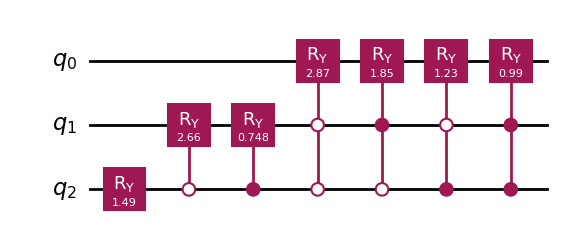

In [56]:
prob_distrib_qc.draw(output='mpl')

In [57]:
prob_distrib_qc = make_qc_for_dict(dict_all_theta)

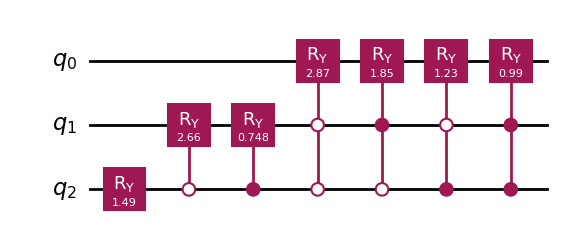

In [58]:
prob_distrib_qc.draw(output='mpl')

In [59]:
circ_prob_distrib = get_state_probabilities(prob_distrib_qc)

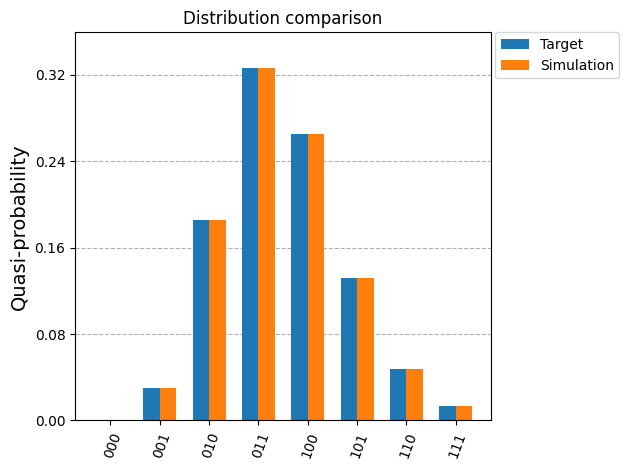

In [60]:
legend=["Target", "Simulation"]
plot_histogram([dict_pn, circ_prob_distrib], legend=legend, title="Distribution comparison", bar_labels=False)

Define a function `make_distribution_circuit`$(n, \mathrm{pricing\_dict}, m)$ that creates the circuit encoding the probability distribution.

In [61]:
def make_distribution_circuit(n, pricing_dict, m):
    """
    Create a quantum circuit that prepares a quantum state encoding a target probability distribution derived from 
    financial data, using a hierarchical approach based on a binary tree structure.
    """

    # Extraction of the probability distribution from the pricing_dict
    _, prob_distribution = make_probability_distribution(n, pricing_dict, m)
    
    # Generate the dicionnary probability distribution at the level n of the tree (the leaves)
    dict_q_n = make_dict_at_n(n, prob_distribution)
    
    # Go back up the tree to calculate the probability distributions at each level and store them in a list of dictionaries
    DictQ = make_all_dictQ(n, dict_q_n)
    
    # Calculate the angles theta for the rotations at each level of the tree and store them in a list of dictionaries
    DictTheta = make_all_dictTheta(DictQ)
    
    # Conctruction of the quantum circuit based on the angles theta obtained previously
    qc = make_qc_for_dict(DictTheta)
    
    return qc

# Full integration

In [62]:
circ_dict = {'n': 3, 'd': 0.01, 'num_stddev': 3, 'm': 3}
K = 2.0

## Creation of the affine functions $f_0$ and $f_1$

<font color=green>

$\textbf{Quantum Payoff Implementation Principles}$

Before coding, it is essential to understand that the output qubit (FuncOutput) carries a probability representing the option's price. However, the full interval $[0,1]$ cannot be used directly because the $sin^2$ function is non-linear. Consequently, we introduce a control parameter $d$ to restrict the computation to a quasi-linear regime.

$\textbf{1. The Foundation : get\_first\_function }$($f_0$)

Even when the option is out-of-the-money (zero payoff so $f(i)=0$), we do not want a probability equal to $0$. We therefore apply an offset to place the qubit in a stable base state, serving as a reference.

- Goal : Position the qubit at the inflection region of the probability curve.
    
- Formula : We know that $y = d \cdot \left(f(i)-\frac{1}{2}\right)$ and $sin^2(\theta) = y + \frac{1}{2}$, so :

\begin{align*}
    sin^2(\theta) = d \cdot \left(f(i)-\frac{1}{2}\right) + \frac{1}{2} &\Rightarrow sin(\theta) = \sqrt{\frac{1-d}{2}} \\
    &\Rightarrow \theta = arcsin \left(\sqrt{\frac{1-d}{2}} \right)
\end{align*}

Finally :
    $$a = arcsin \left(\sqrt{\frac{1-d}{2}}\right), \quad b = 0$$

- Interpretation : If $d = 0.25$, the base probability is approximately $0.375$. This represents our financial zero.

$\textbf{2. The Profit Slope : get\_second\_function}$($f_1$)

This function encodes the payoff growth of a Call option. The payoff depends on the difference between the current price $S_i$ and the strike price $K$. The idea is to transform this difference $(S_i - K)$ into an additional rotation angle (note that the projection of K in our grid is $s_L$). 

The components are:
- $step = \frac{S_{max} - S_{min}}{2^n - 1}$
- Payoff function normalization since it between $s_L$ and $S_{max}$

$$ f_1(i) = \frac{S_i}{s_L} \Rightarrow f_{1\_norm}(i) = \frac{S_i-s_L}{S_{max}-s_L}$$

$S_i = S_{min} + step \cdot i$

Finally :
\begin{align*}
    d \cdot \left(f_{1\_norm}(i)-\frac{1}{2}\right) + \frac{1}{2} &= d \cdot \left(\frac{S_{min} + step \cdot i - s_L}{S_{max}-s_L} -\frac{1}{2}\right) + \frac{1}{2} \\
    &= d \cdot \left(\frac{S_{min} - s_L}{S_{max}-s_L} -\frac{1}{2}\right) + \frac{1}{2} + d \cdot \frac{step}{S_{max}-s_L} \cdot i
\end{align*}

$$a = d \cdot \left(\frac{S_{min} - s_L}{S_{max}-s_L} -\frac{1}{2}\right) + \frac{1}{2}, \quad b = d \cdot \frac{step}{S_{max}-s_L} $$

$\textbf{In summary}$ we are not directly computing a price, but rather encoding a qubit inclination. The function $f_0$ sets the baseline (floor), while $f_1$ adds an inclination proportional to the payoff whenever the asset price exceeds the strike.

In [63]:
def get_first_function(circ_dict):
    d = circ_dict['d']
    a = np.arcsin(np.sqrt((1 - d) * 0.5))
    b = 0.0 
    return a, b

def get_second_function(circ_dict, pr_dict, K):
    """ 
    Payoff function of the option
    """
    n = circ_dict['n']
    d = circ_dict['d']
    m = circ_dict['num_stddev']
    S_min, S_max = get_boundary(n, pr_dict, m)

    # Get the price in the grid that is aligned with the strike K
    sL = align(n, K, pr_dict, m)[1]
    
    # Step of each interval in the grid of final prices
    step = (S_max - S_min) / (2**n - 1)
    
    # Slope of the affine function
    b = (d * step) / ((S_max - sL))
    # Intercept of the affine function
    a = (d * ((S_min - sL) / (S_max - sL)) - 0.5) + 0.5
    
    return a, b

Compare the expectation we are computing with the expectation of its sine approximation

In [64]:
def compare_expect(circ_dict, price_dict, K):
    n = circ_dict['n']
    num_stddev = circ_dict['num_stddev']
    d = circ_dict['d']
    _, prdist = make_probability_distribution(n, price_dict, num_stddev)
    last_prices = make_final_price_grid(n, price_dict, num_stddev)
    L, sL = align(n, K, price_dict, num_stddev)
    sM = last_prices[-1]
    sum = 0
    mean_sin = 0
    a1, b1 = get_first_function(circ_dict)
    a2, b2 = get_second_function(circ_dict, price_dict, K)  
    for i in range(0, 2**n):
        fi = (last_prices[i] - sL)*(i>=L)/(sM - sL)
        f_0_1 = a1 + b1*i + (a2 + b2 * i) * (i>=L)
        sum += fi* prdist[i]
        mean_sin += np.sin(f_0_1)**2* prdist[i]
    mean_f = d*sum + (1-d)*0.5
    return mean_f, mean_sin

In [65]:
expect, sin_expect = compare_expect(circ_dict, price_dict, K)

In [66]:
expect, sin_expect

(np.float64(0.49681293768068807), np.float64(0.49681290065528705))

In [67]:
def make_first_function_circuit(cr_dict):
    n = cr_dict['n']
    a, b = get_first_function(cr_dict)
    res = encode_affine_function(n, a, b)
    return res

def make_second_function_circuit(cr_dict, pr_dict, K):
    n = cr_dict['n']
    a, b = get_second_function(cr_dict, pr_dict, K)
    res = encode_affine_function(n, a, b)
    return res

## Comparison circuit

In [68]:
def make_comparison_circuit(circ_dict, price_dict, K):
    n = circ_dict['n']
    num_stddev = circ_dict['num_stddev']
    
    L = align(n, K, price_dict, num_stddev)[0]
    base_comparator = make_comparator(n, L) # This gate expects 2n qubits: 1 for the output, n for the input, and n-1 for the ancillas.
    
    # Declaration of the quantum registers for the global circuit
    qr_out = QuantumRegister(1, 'CMPOutput')
    qr_anc = QuantumRegister(n-1, 'AncillaCMP')
    qr_inp = QuantumRegister(n, 'Input')
    
    # Comparator circuit construction with the correct mapping of the qubits from the base_comparator to the global circuit
    qc = QuantumCircuit(qr_out, qr_anc, qr_inp, name="cmp")
    
    # Construction of the mapping of the qubits
    # Pin 0 (Gate) -> must go to qr_out[0] (Index 0 of circuit qc)
    output_index = [0]
    
    # Pins 1 to n (Gate) -> must go to qr_inp (Indices n to 2n-1 of circuit qc)
    inputs_indices = list(range(n, 2*n)) 
    
    # Pins n+1 to 2n-1 (Gate) -> must go to qr_anc (Indices 1 to n-1 of circuit qc)
    ancilla_indices = list(range(1, n)) 
    
    # We concatenate the indices to have the correct order of qubits for the gate application
    # [Result, Inputs, Ancillas]
    qubit_mapping = output_index + inputs_indices + ancilla_indices
    
    qc.append(base_comparator.to_gate(), qubit_mapping)
    
    return qc

## Integration

In [69]:
def integration(circ_dict, price_dict, K):
    n = circ_dict['n']
    m = circ_dict['m']
    num_stddev = circ_dict['num_stddev']
    input = QuantumRegister(n, name="Input")
    funcOutput = QuantumRegister(1, name="FuncOutput")
    CMPancilla = QuantumRegister(n-1, name="AncillaCMP")
    CMPoutput = QuantumRegister(1, name="CMPOutput")
    prob_dist_qc = make_distribution_circuit(n, price_dict, num_stddev)
    prob_dist_gate = prob_dist_qc.to_gate(label='prob_dist')
    f0_qc = make_first_function_circuit(circ_dict)
    f0_gate = f0_qc.to_gate(label='f0')
    f1_qc = make_second_function_circuit(circ_dict, price_dict, K)
    f1_gate = f1_qc.to_gate(label='f1')
    ctl_f1_gate = f1_gate.control(1)
    cmp_qc = make_comparison_circuit(circ_dict, price_dict, K)
    cmp_gate = cmp_qc.to_gate(label='cmp')
    res = QuantumCircuit(CMPoutput, CMPancilla, funcOutput, input)
    res.append(prob_dist_gate, input)
    res.append(cmp_gate, CMPoutput[:] + CMPancilla[:] + input[:])
    res.append(f0_gate, funcOutput[:] + input[:])
    res.append(ctl_f1_gate, CMPoutput[:] + funcOutput[:] + input[:])
    return res



In [70]:
qc_pricer = integration(circ_dict, price_dict, K)

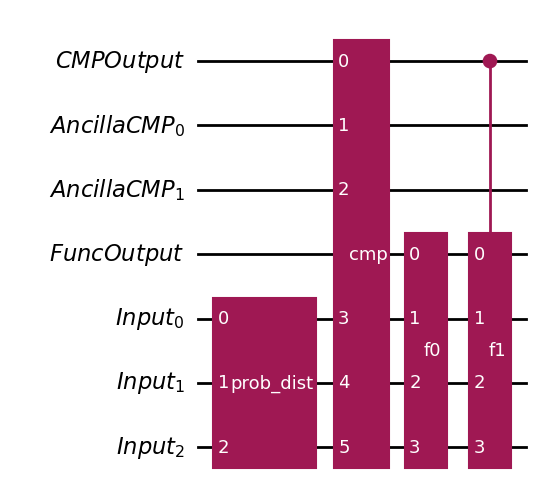

In [71]:
qc_pricer.draw('mpl')


In [72]:
def qae_eval(qc_pricer, num_shots):
    obj_qubits = qc_pricer.find_bit(qc_pricer.qregs[3][0])
    eps = 1.0/num_shots
    sampler = Sampler()
    problem = EstimationProblem(state_preparation=qc_pricer, objective_qubits=[obj_qubits.index]) 
    iae = FasterAmplitudeEstimation(
        maxiter=num_shots,  # Target accuracy
        delta=0.05,  # Confidence level
        sampler = sampler
    )
    result = iae.estimate(problem).estimation
    return result

In [73]:
res = qae_eval(qc_pricer, 7)

In [74]:
print(f'sin_expect: {sin_expect}, res: {res}')

sin_expect: 0.49681290065528705, res: 0.5019435756270685


<font color=green>

$\textbf{OVERALL SUMMARY : OPTION PRICING VIA THE QAE ALGORITHM}$

$\textbf{1. Introduction and Objective}$

The objective of this project is to evaluate the price of a European Call Option using quantum computing. Unlike classical (Monte Carlo) methods, the quantum approach uses Quantum Amplitude Estimation (QAE), theoretically offering a quadratic acceleration of computation time.

The price of an option is the expected value of its future payoff, discounted to today's date. Mathematically, we aim to calculate :
$$ E\left[max(S-K, 0)\right] = \int p(S) \cdot payoff(S) \cdot dS $$

$\textbf{2. Algorithm Architecture}$

The construction of the Pricer circuit is based on four modular pillars.

A. Loading the Probability Distribution

We encode the price distribution of the asset (S) in a register of n qubits. Each binary state $|i\rangle$ represents a possible price $S_i$.

- Action : The circuit generates a state $|\psi \rangle= \sum_{i=0}^{2n−1}p_i|i\rangle.$
- Result : The amplitude of each state corresponds to the probability that the stock will reach that price.

B. Linearization of the Payoff ($f_0$ and $f_1$)

In quantum mechanics, a numerical value is encoded as a probability via the rotation of a qubit. However, the probability is related to the square of the $sin$ ($sin^2(\theta)$), which is not linear.

To circumvent this, we use an approximation on a reduced interval $[1−d,1+d]$:

- $f_0$ (The Offset) : Places the output qubit (FuncOutput) in a ground state even if the option is out of play ($price \lt Strike$). This is our financial zero.

- $f_1$ (The Slope) : Adds an additional spin proportional to the profit ($S_i−K$) if the option is in play.

C. The Quantum Comparator (The Strike Condition)

This is the logical brain of the circuit. It must determine if the current price $S_i$ is greater than or equal to the strike price $K$.

- Operation : It compares the input bit by bit to the threshold L (the indexed Strike).
- Output : It activates a witness qubit CMPOutput (set to $|1\rangle$) only if $S_i \ge K$.

This witness qubit enables the application of the profit function $f_1$.

D. Integration and Mapping

The final step is to assemble these blocks. The major technical challenge is qubit mapping : ensuring that each wire (qubit) of the overall circuit is connected to the correct pin of the sub-circuits (Input, Ancillas, Output).

$\textbf{3. Amplitude Estimation (QAE)}$

Once the complete circuit is built, we do not measure it directly (which would be equivalent to performing classic Monte Carlo simulations). We use the Faster Amplitude Estimation (FAE) algorithm.

Principle : The circuit is used as a reflection operator. By analyzing the accumulated phase, the algorithm extracts with extreme precision the probability of finding the FuncOutput qubit in the state $|1\rangle$.

$\textbf{4. Conclusion and Results}$

This project demonstrates the power of modularity in quantum computing :

- Accuracy : By adjusting the control parameter $d$ and the number of QAE iterations, we achieve convergence to the theoretical value (given by Black-Scholes).

- Modularity : Each component (comparator, distribution, rotation functions) can be tested separately before being integrated into the final pricer circuit.